In [1]:
import pandas as pd

df = pd.read_csv("../dataset.csv")

print(df.head())


/tmp/ipykernel_45620/64371187.py:3: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dataset.csv")


         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df['loan_status'].value_counts())


(2260701, 151)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'a

In [3]:
print(df['loan_status'].unique())

['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']


In [4]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

print(df['target'].value_counts())

target
0    1076751
1     268559
Name: count, dtype: int64


In [5]:
drop_cols = [
      # identifiers
      'id', 'member_id', 'url', 'desc', 'title', 'emp_title', 'zip_code',

      # target leakage — these columns only exist AFTER loan is issued
      # using them would be cheating, model wouldn't work in real life
      'loan_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
      'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
      'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
      'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',

      # 99% missing data columns 
      'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
      'deferral_term', 'hardship_amount', 'hardship_start_date',
      'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
      'hardship_dpd', 'hardship_loan_status',
      'orig_projected_additional_accrued_interest',
      'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    
      'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
      'settlement_date', 'settlement_amount', 'settlement_percentage',
      'settlement_term',

      # mostly missing
      'annual_inc_joint', 'dti_joint', 'verification_status_joint',
      'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
      'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
      'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
      'sec_app_open_act_il', 'sec_app_num_rev_accts',
      'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
      'sec_app_mths_since_last_major_derog',

      # other useless
      'pymnt_plan', 'policy_code', 'application_type', 'disbursement_method'
  ]

df = df.drop(columns=drop_cols)



In [6]:
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(15))

(1345310, 90)
mths_since_last_record            1116755
mths_since_recent_bc_dlq          1026290
mths_since_last_major_derog        991560
mths_since_recent_revol_delinq     895348
il_util                            880294
mths_since_rcnt_il                 821928
all_util                           807765
total_cu_tl                        807713
inq_last_12m                       807713
open_acc_6m                        807713
open_act_il                        807712
max_bal_bc                         807712
open_il_24m                        807712
open_il_12m                        807712
open_rv_24m                        807712
dtype: int64


In [7]:
mis_threshold = len(df) * 0.4
df = df.drop(columns=df.columns[df.isnull().sum() > mis_threshold])

print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(10))

(1345310, 71)
mths_since_recent_inq    174071
num_tl_120dpd_2m         117401
mo_sin_old_il_acct       105575
emp_length                78511
pct_tl_nvr_dlq            67681
avg_cur_bal               67549
num_rev_accts             67528
mo_sin_old_rev_tl_op      67528
mo_sin_rcnt_rev_tl_op     67528
num_actv_bc_tl            67527
dtype: int64


In [8]:
print(type(df['revol_util']))

<class 'pandas.core.series.Series'>


In [9]:
df['term'] = df['term'].str.extract('(\d+)').astype(float)
print(df['term'].unique())

emp_map = {
    '< 1 year' : 0, '1 year' : 1, '2 years' : 2, '3 years' : 3, '4 years' : 4, '5 years' : 5, '6 years': 6, '7 years' : 7, '8 years' : 8, '9 years' : 9 , '10+ years' : 10
}

df['emp_length'] = df['emp_length'].map(emp_map)




<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_45620/3074323476.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['term'] = df['term'].str.extract('(\d+)').astype(float)


[36. 60.]


In [10]:
df['debt_to_installment'] = df['loan_amnt'] / df['installment']

df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high'])/2

df = df.drop(columns=['fico_range_low','fico_range_high'])

df['funded_ratio'] = df['funded_amnt']/ df['loan_amnt']

df['revol_util_bucket'] = pd.cut(
    df['revol_util'],
    bins=[0,30,60,80,100],
    labels=['low','medium','high','very_high']
)

In [11]:
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(10))
df = df.drop(columns=['last_fico_range_low', 'last_fico_range_high', 'last_credit_pull_d'], errors='ignore')

(1345310, 73)
mths_since_recent_inq    174071
num_tl_120dpd_2m         117401
mo_sin_old_il_acct       105575
emp_length                78511
pct_tl_nvr_dlq            67681
avg_cur_bal               67549
mo_sin_rcnt_rev_tl_op     67528
num_rev_accts             67528
mo_sin_old_rev_tl_op      67528
mo_sin_rcnt_tl            67527
dtype: int64


In [12]:
print(df['term'].unique())
print(df['emp_length'].unique)

[36. 60.]
<bound method Series.unique of 0          10.0
1          10.0
2          10.0
4           3.0
5           4.0
           ... 
2260688     5.0
2260690     9.0
2260691     3.0
2260692    10.0
2260697     6.0
Name: emp_length, Length: 1345310, dtype: float64>


In [14]:
import numpy as np
# no recnt inqiury means fill it with max values (been a long time )
df['mths_since_recent_inq'] = df['mths_since_recent_inq'].fillna(df['mths_since_recent_inq'].max())
# count columns — missing means 0
df['num_tl_120dpd_2m'] = df['num_tl_120dpd_2m'].fillna(0)
df['num_tl_90g_dpd_24m'] = df['num_tl_90g_dpd_24m'].fillna(0)
df['num_accts_ever_120_pd'] = df['num_accts_ever_120_pd'].fillna(0)
# old account age — missing means no installment account, fill with 0
df['mo_sin_old_il_acct'] = df['mo_sin_old_il_acct'].fillna(0)
# emp_length  missing means unknown we fill with median
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())
# all remaining numeric nulls

print(df.isnull().sum().sort_values(ascending=False).head(10))
print(df.shape)


  # payment burden — what % of monthly income goes to installment
df['payment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
# delinquency ratio

df['delinq_ratio'] = df['delinq_2yrs'] / (df['total_acc'] + 1)
# credit usage intensity

df['credit_intensity'] = df['revol_bal'] / (df['total_rev_hi_lim'] + 1)
# open account ratio 
df['open_acc_ratio'] = df['open_acc'] / (df['total_acc'] + 1)



# Now drop the original date columns
df = df.drop(columns=['earliest_cr_line'])


pct_tl_nvr_dlq           67681
avg_cur_bal              67549
mo_sin_rcnt_rev_tl_op    67528
mo_sin_old_rev_tl_op     67528
num_rev_accts            67528
tot_coll_amt             67527
mo_sin_rcnt_tl           67527
tot_cur_bal              67527
num_bc_tl                67527
tot_hi_cred_lim          67527
dtype: int64
(1345310, 73)


KeyError: "['earliest_cr_line'] not found in axis"

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.preprocessing import OneHotEncoder

X = df.drop('target', axis=1)
y = df['target']

#using time based spilit is better
df['issue_d'] = pd.to_datetime(df["issue_d"],format="%b-%Y", errors='coerce') # converting issue_d into actual datetime 
df = df.sort_values("issue_d").reset_index(drop=True) # sorting dataset 

#create splits 
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

#slicing data by time
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

#train 
X_train = train_df.drop('target', axis=1)
y_train = train_df["target"]
#validation
X_val = val_df.drop('target',axis=1)
y_val = val_df['target']
#test 
X_test = test_df.drop('target',axis=1)
y_test = test_df['target']


print(X_train.shape,X_test.shape)
print(y_train.value_counts(normalize=True))

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

num_trs = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

txt_trs = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])



(941716, 72) (201797, 72)
target
0    0.813093
1    0.186907
Name: proportion, dtype: float64


/home/Bhavya/Desktop/ML/CreditCardFraud/.ML/lib64/python3.14/site-packages/xgboost/core.py:751: UserWarning: [14:40:13] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           0       0.89      0.58      0.70    159201
           1       0.32      0.73      0.45     42596

    accuracy                           0.61    201797
   macro avg       0.61      0.66      0.57    201797
weighted avg       0.77      0.61      0.65    201797

Roc Auc is: 0.7191456502320803
CM is: [[92512 66689]
 [11300 31296]]


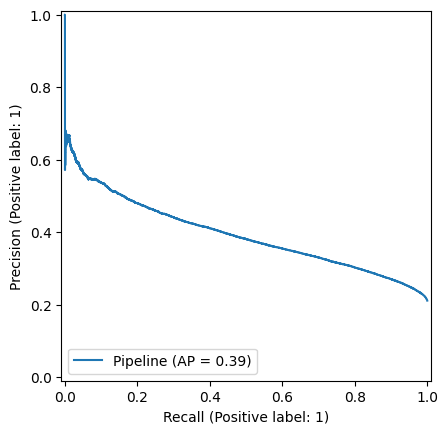

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,PrecisionRecallDisplay
from sklearn.compose import ColumnTransformer

col_trns = ColumnTransformer(transformers=[
    ('num', num_trs, num_cols),
    ('txt', txt_trs, cat_cols)
])

pipe = Pipeline(steps=[
    ('preprocessing',col_trns),
    ('Xgboost', XGBClassifier(
        n_estimators = 500,
        learning_rate=0.2,
        max_depth = 4,
        subsample=0.93,
        colsample_bytree=0.95,
        min_child_weight=6,
        random_state=42,
        scale_pos_weight = 4.5,
        gamma = 3.77,
        device='cuda'
    ))
])

pipe.fit(X_train,y_train)

pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:,1]

pred  = (prob>=0.45).astype(int)
print(f"{classification_report(y_test,pred)}")
print(f"Roc Auc is: {roc_auc_score(y_test,prob)}")

PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test)
print(f"CM is: {confusion_matrix(y_test,pred)}")

# OPTUNA 

In [74]:
import optuna
from sklearn.model_selection import cross_val_score
def objective(trail):
    params={
        'n_estimators': trail.suggest_int('n_estimator',100,500),
        'max_depth': trail.suggest_int('max_depth', 3,8),
        'learning_rate': trail.suggest_float('learning_rate',0.01,0.3),
        'subsample': trail.suggest_float('subsample',0.6,1.0),
        'colsample_bytree': trail.suggest_float('colsample_bytree',0.6,1.0),
        'min_child_weight': trail.suggest_int('min_child_weight',1,10),
        'gamma' : trail.suggest_float('gamma', 0,5),
        'scale_pos_weight' :4,
        'random_state' : 42,
        'eval_metric' : 'auc',
        'device' : 'cuda'
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train,y_train,cv=3,scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)

print("Best Params: ", study.best_params)
print("Best ROC-AUC: ", study.best_value)


[I 2026-05-30 15:29:27,611] A new study created in memory with name: no-name-3e15fa38-1730-4bd8-bb82-d51a0e0132e9
[I 2026-05-30 15:29:43,620] Trial 0 finished with value: 0.7311188943974779 and parameters: {'n_estimator': 366, 'max_depth': 7, 'learning_rate': 0.030053660144311822, 'subsample': 0.908818060155516, 'colsample_bytree': 0.8956888517268933, 'min_child_weight': 10, 'gamma': 3.012265835360619}. Best is trial 0 with value: 0.7311188943974779.
[I 2026-05-30 15:29:54,500] Trial 1 finished with value: 0.7337469585827107 and parameters: {'n_estimator': 478, 'max_depth': 4, 'learning_rate': 0.15134443909520462, 'subsample': 0.934562182478314, 'colsample_bytree': 0.9550432193260224, 'min_child_weight': 9, 'gamma': 3.7798633167925533}. Best is trial 1 with value: 0.7337469585827107.
[I 2026-05-30 15:30:03,212] Trial 2 finished with value: 0.7313388824686129 and parameters: {'n_estimator': 327, 'max_depth': 4, 'learning_rate': 0.1073347902115165, 'subsample': 0.8116168920245237, 'colsa

Best Params:  {'n_estimator': 478, 'max_depth': 4, 'learning_rate': 0.15134443909520462, 'subsample': 0.934562182478314, 'colsample_bytree': 0.9550432193260224, 'min_child_weight': 9, 'gamma': 3.7798633167925533}
Best ROC-AUC:  0.7337469585827107


 # MLFLOW 


/home/Bhavya/Desktop/ML/CreditCardFraud/.ML/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/06/01 21:12:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 21:13:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 21:13:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which 

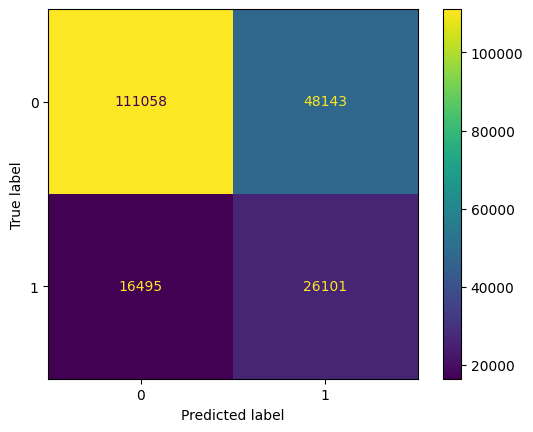

In [12]:
import mlflow
import mlflow.sklearn
import matplotlib as plt
from sklearn.metrics import ConfusionMatrixDisplay

mlflow.sklearn.autolog()

mlflow.set_experiment('Loan_Defaulter_Detection')

with mlflow.start_run(run_name='XGBoost'):
    pipe.fit(X_train,y_train)
    pred_test = pipe.predict(X_test)
    prob_test = pipe.predict_proba(X_test)[:,1]
    report = classification_report(y_test,pred_test)
    roc_auc_test = roc_auc_score(y_test,prob_test)
    cm_test = ConfusionMatrixDisplay.from_predictions(y_test,pred_test)

    mlflow.log_metric('roc_auc',roc_auc_test)

    mlflow.sklearn.log_model(
        sk_model=pipe,
        artifact_path='model',
        registered_model_name='Loan_Defaulter_Detection'
    )



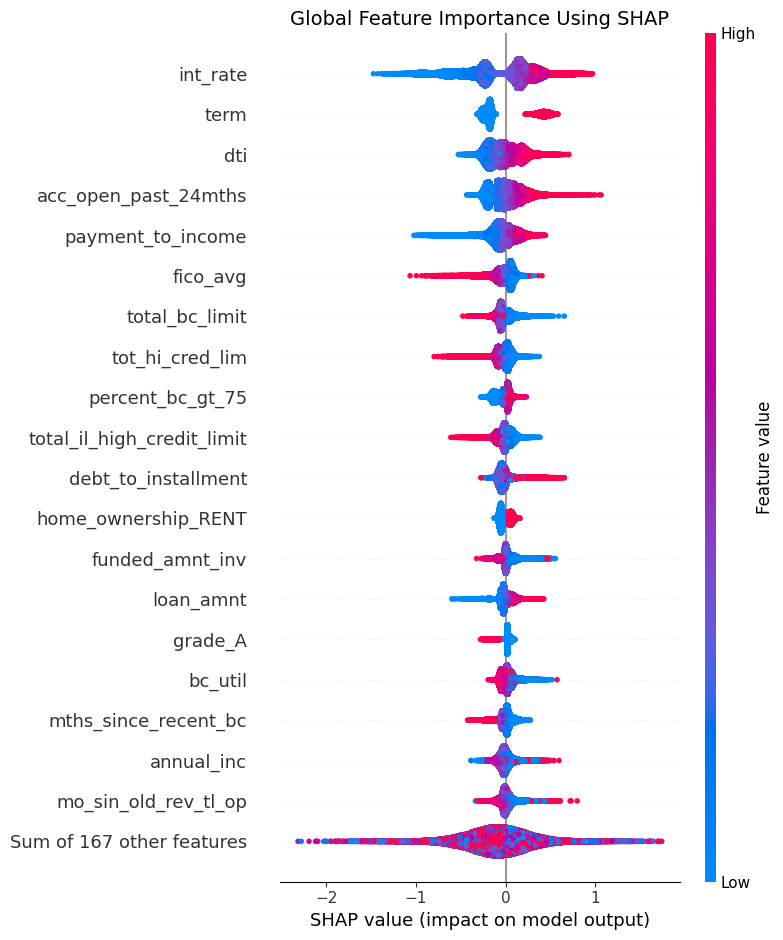

In [ ]:
import pandas as pd
import shap
import matplotlib.pylab as plt
import numpy

xgb_model = pipe.named_steps['Xgboost']  
feature_names = col_trns.get_feature_names_out()
feature_names = [
    name.split("__")[-1]
    for name in feature_names
]
X_test_transformed = pipe[:-1].transform(X_test) 

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_transformed_df)

shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("Global Feature Importance Using SHAP", fontsize=14)
plt.tight_layout()
plt.savefig("shap_plot.png", bbox_inches="tight")

In [17]:
import joblib 

joblib.dump(pipe,'saved_model.pkl')

['saved_model.pkl']

In [19]:

print(df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankr

In [20]:
majority_class = df[df['target'] == 0]
minority_class = df[df['target'] == 1]

total_sample_size = 10000 

majority_size = int(total_sample_size * 0.8) # 8000 rows
minority_size = int(total_sample_size * 0.2) # 2000 rows


majority_sample = majority_class.sample(n=majority_size, random_state=42)
minority_sample = minority_class.sample(n=minority_size, random_state=42)

imbalanced_df = pd.concat([majority_sample, minority_sample])

final_sample = imbalanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(final_sample['target'].value_counts(normalize=True))

final_sample.to_csv('sample_dataset.csv', index=False)

print(final_sample.columns.tolist())

target
0    0.8
1    0.2
Name: proportion, dtype: float64
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_